In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('used_cars.csv')
df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Data Exploration

In [5]:
df.shape

(4009, 12)

In [6]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [8]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


EDA & Data Preprocessing

In [9]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [10]:
df = df.ffill()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
# Fill missing values

df['fuel_type'] = df['fuel_type'].fillna('Unknown')
df['accident'] = df['accident'].fillna('No Info')
df['clean_title'] = df['clean_title'].fillna('No Info')

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [16]:
pd.set_option('display.max_rows',1700)

In [17]:
cols = ['brand','model','fuel_type','engine','transmission','ext_col','int_col','accident']
unique_data = []

for col in cols:
    unique_data.append({
        "Column": col,
        "Unique Count": df[col].nunique(),
        "Unique Values": df[col].unique()
    })

unique_df = pd.DataFrame(unique_data)
unique_df


,Column,Unique Count,Unique Values
0,brand,57,"[Ford, Hyundai, Lexus, INFINITI, Audi, Acura, ..."
1,model,1898,"[Utility Police Interceptor Base, Palisade SEL..."
2,fuel_type,7,"[E85 Flex Fuel, Gasoline, Hybrid, Diesel, Plug..."
3,engine,1146,[300.0HP 3.7L V6 Cylinder Engine Flex Fuel Cap...
4,transmission,62,"[6-Speed A/T, 8-Speed Automatic, Automatic, 7-..."
5,ext_col,319,"[Black, Moonlight Cloud, Blue, Glacier White M..."
6,int_col,156,"[Black, Gray, Ebony., Green, Pimento / Ebony, ..."
7,accident,2,"[At least 1 accident or damage reported, None ..."


In [18]:
pd.reset_option('display.max_rows')

In [19]:
df.drop(columns=['clean_title'], inplace=True)


In [20]:
def simplify_brand(x):
    economy_brands = [ 'Ford', 'Toyota', 'Honda', 'Nissan', 'Hyundai', 'Kia', 'Mazda', 'Subaru', 'Volkswagen']
    luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Cadillac', 'Acura', 'Infiniti']
    exotic_brands = ['Ferrari', 'Lamborghini', 'McLaren', 'Bugatti', 'Pagani', 'Koenigsegg', 'Jaguar', 'Porsche', 'Maserati', 'Aston Martin', 'Bentley', 'Rolls-Royce']
    electric_brands = ['Tesla', 'Rivian', 'Lucid Motors', 'NIO', 'XPeng', 'BYD', 'Fisker']

    if x in economy_brands:
        return 'Economy'
    elif x in luxury_brands:
        return 'Luxury'
    elif x in exotic_brands:
        return 'Exotic'
    elif x in electric_brands:
        return 'Electric'
    else:
        return 'Other'

df['brand'] = df['brand'].apply(simplify_brand)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300"
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005"
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598"
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500"
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999"


In [21]:
df['model_main'] = df['model'].apply(lambda x: x.split()[0])
df.head()

#Example
#model	            model_main
#Corolla Altis	    Corolla
#Swift Dzire	    Swift
#BMW X5 xDrive	    BMW

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Utility
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Palisade
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",RX
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Q50
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Q3


In [22]:
top_models = df['model_main'].value_counts().nlargest(10).index
df['model_main'] = df['model_main'].apply(lambda x: x if x in top_models else 'Other')
df.head()

#Example

#Before: model_main     After: model_main
#Swift                  Swift
#BMW                    BMW
#Civic                  Civic
#RareCar1               Other
#RareCar2               Other

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Other
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Other
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",Other
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Other
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Other


In [23]:
df['model_main'].value_counts()

model_main
Other       3290
Rover        130
Model         87
911           80
Wrangler      73
F-150         64
Mustang       61
Corvette      61
AMG           60
1500          56
F-250         47
Name: count, dtype: int64

In [24]:
df['fuel_type'].unique()

<StringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',         'Diesel',
 'Plug-In Hybrid',              '–',  'not supported']
Length: 7, dtype: str

In [25]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')


In [26]:
def simplify_fuel(x):
    if x == 'Gasoline':
        return 'Gasoline'
    elif 'Hybrid' in str(x):
        return 'Hybrid'
    elif x == 'Diesel':
        return 'Diesel'
    elif x == 'Electric':
        return 'Electric'
    else:
        return 'Other'

df['fuel_type'] = df['fuel_type'].apply(simplify_fuel)
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,"$10,300",Other
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,"$38,005",Other
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,"$54,598",Other
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,"$15,500",Other
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,"$34,999",Other


In [27]:
df['fuel_type'].value_counts()

fuel_type
Gasoline    3453
Hybrid       235
Other        199
Diesel       122
Name: count, dtype: int64

In [28]:
engine_str = df['engine'].astype(str)
df['HP'] = engine_str.str.extract(r'(\d+)\s*HP', expand=False).astype(float)
df['Engine_size'] = engine_str.str.extract(r'(\d+\.\d+)', expand=False).astype(float)
df['Cylinders'] = engine_str.str.extract(r'(\d+)(?!.*\d)', expand=False).astype(float)

#| engine         | HP  | Engine_size | Cylinders |
#|-------------- | --- | ----------- | --------- |
#| 300 HP 3.0L V6 | 300 | 3.0         | 6         |
#| 150 HP 1.5L V4 | 150 | 1.5         | 4         |


In [29]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type         0
engine            0
transmission      0
ext_col           0
int_col           0
accident          0
price             0
model_main        0
HP              808
Engine_size     103
Cylinders        78
dtype: int64

In [30]:
df['HP'] = df['HP'].fillna(df['HP'].median())
df['Engine_size'] = df['Engine_size'].fillna(df['Engine_size'].median())
df['Cylinders'] = df['Cylinders'].fillna(df['Cylinders'].median())

In [31]:
df.isna().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
price           0
model_main      0
HP              0
Engine_size     0
Cylinders       0
dtype: int64

In [32]:
def simplify_transmission(x):
    x = str(x)
    if 'A/T' in x or 'Automatic' in x:
        return 'Automatic'
    elif 'M/T' in x or 'Manual' in x:
        return 'Manual'
    elif 'CVT' in x:
        return 'CVT'
    else:
        return 'Other'

df['transmission'] = df['transmission'].apply(simplify_transmission)

In [33]:
df['transmission'].value_counts()

transmission
Automatic    3148
Other         426
Manual        372
CVT            63
Name: count, dtype: int64

In [34]:
main_colors = ['white', 'black', 'silver', 'gray', 'red', 'blue']

df['ext_col'] = df['ext_col'].str.lower().apply(
    lambda x: next((color.capitalize() for color in main_colors if color in str(x)), 'Other')
)

df['int_col'] = df['int_col'].str.lower().apply(
    lambda x: next((color.capitalize() for color in main_colors if color in str(x)), 'Other')
)
#| ext_col (before) | ext_col (after) |
#| ---------------- | --------------- |
#| White            | White           |
#| Yellow           | Other           |
#| Dark Blue        | Other ❗        |
#| Black            | Black           |

df['ext_col'].value_counts()



ext_col
Black     1016
White      922
Gray       535
Silver     421
Other      409
Blue       395
Red        311
Name: count, dtype: int64

In [35]:
df['int_col'].value_counts()

int_col
Black     2155
Other     1058
Gray       483
Red        134
White      131
Blue        32
Silver      16
Name: count, dtype: int64

In [36]:
df['accident'] = df['accident'].replace({'None reported': 'No', 'None ': 'No', 'Accident reported': 'Yes'})
df['accident'] = df['accident'].fillna('No Info')


In [37]:
df['car_age'] = pd.Timestamp.now().year - df['model_year']


In [38]:
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price,model_main,HP,Engine_size,Cylinders,car_age
0,Economy,Utility Police Interceptor Base,2013,"51,000 mi.",Other,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,Automatic,Black,Black,At least 1 accident or damage reported,"$10,300",Other,0.0,300.0,6.0,13
1,Economy,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,Automatic,Other,Gray,At least 1 accident or damage reported,"$38,005",Other,0.0,3.8,24.0,5
2,Luxury,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,No,"$54,598",Other,0.0,3.5,5.0,4
3,Other,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,Automatic,Black,Black,No,"$15,500",Other,0.0,354.0,6.0,11
4,Luxury,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,Automatic,White,Black,No,"$34,999",Other,0.0,2.0,16.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Exotic,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,Automatic,Other,Other,No,"$349,950",Other,0.0,6.0,48.0,3
4005,Luxury,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Other,Black,Black,No,"$53,900",Other,0.0,349.0,6.0,4
4006,Exotic,Taycan,2022,"2,116 mi.",Gasoline,Electric,Automatic,Black,Black,No,"$90,998",Other,0.0,290.0,6.0,4
4007,Economy,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,Automatic,Blue,Black,No,"$62,999",F-150,0.0,450.0,6.0,6


In [39]:
df.drop(columns=['brand', 'model', 'model_year', 'engine'], inplace=True)
df


,milage,fuel_type,transmission,ext_col,int_col,accident,price,model_main,HP,Engine_size,Cylinders,car_age
0,"51,000 mi.",Other,Automatic,Black,Black,At least 1 accident or damage reported,"$10,300",Other,0.0,300.0,6.0,13
1,"34,742 mi.",Gasoline,Automatic,Other,Gray,At least 1 accident or damage reported,"$38,005",Other,0.0,3.8,24.0,5
2,"22,372 mi.",Gasoline,Automatic,Blue,Black,No,"$54,598",Other,0.0,3.5,5.0,4
3,"88,900 mi.",Hybrid,Automatic,Black,Black,No,"$15,500",Other,0.0,354.0,6.0,11
4,"9,835 mi.",Gasoline,Automatic,White,Black,No,"$34,999",Other,0.0,2.0,16.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,714 mi.,Gasoline,Automatic,Other,Other,No,"$349,950",Other,0.0,6.0,48.0,3
4005,"10,900 mi.",Gasoline,Other,Black,Black,No,"$53,900",Other,0.0,349.0,6.0,4
4006,"2,116 mi.",Gasoline,Automatic,Black,Black,No,"$90,998",Other,0.0,290.0,6.0,4
4007,"33,000 mi.",Gasoline,Automatic,Blue,Black,No,"$62,999",F-150,0.0,450.0,6.0,6


In [40]:
df['milage'] = df['milage'].astype(str).str.replace(',', '', regex=False)
df['price'] = df['price'].astype(str).str.replace(',', '', regex=False)
df['accident'] = df['accident'].fillna(df['accident'].mode()[0])

df['milage'] = df['milage'].str.extract(r'(\d+)', expand=False).astype(float)
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)

#You should see:
#milage ? float ?
#price ? float ?
#accident ? no nulls ?


Visulization

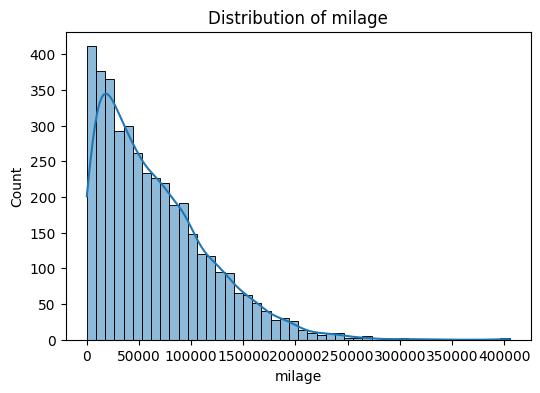

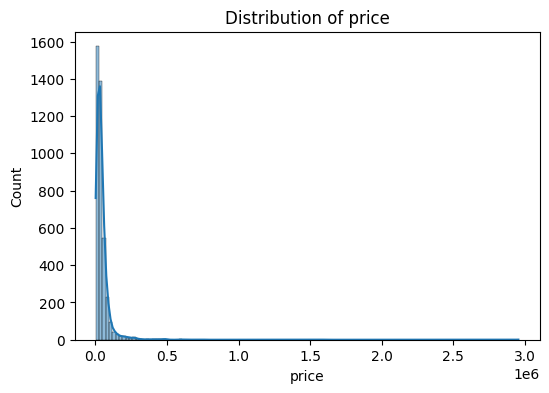

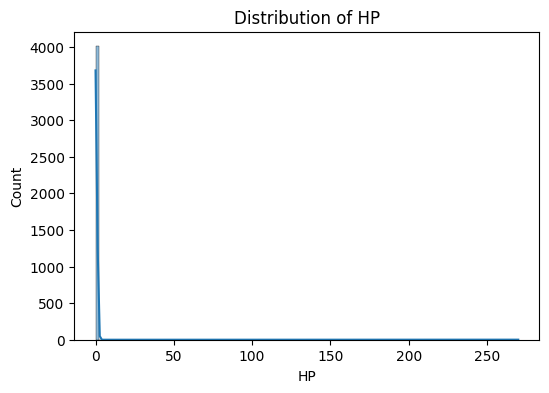

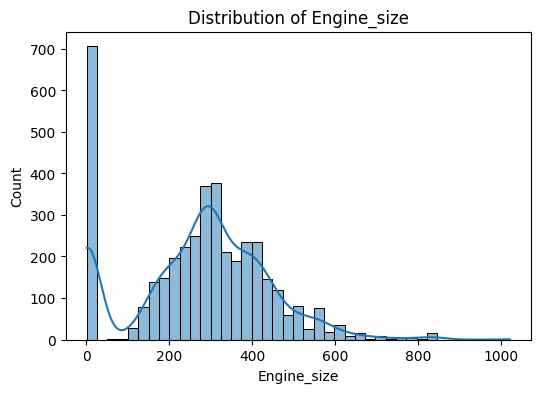

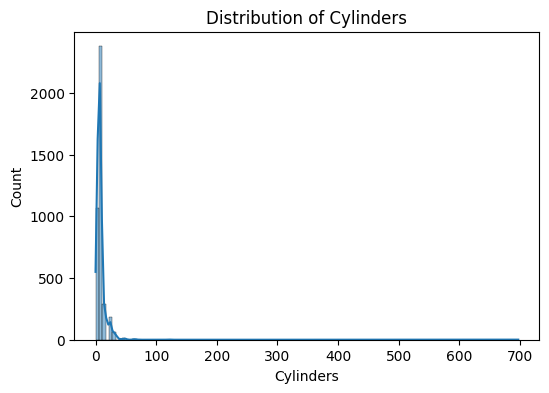

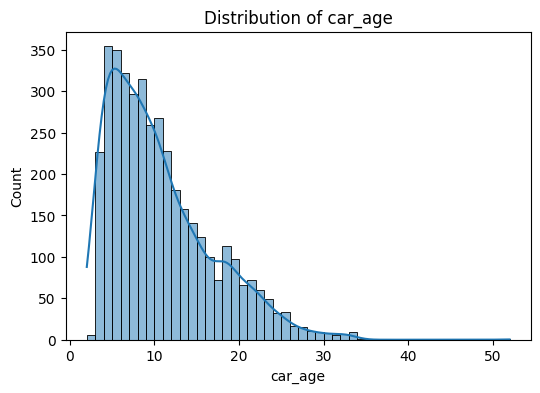

In [41]:
numeric_cols = ['milage', 'price', 'HP', 'Engine_size', 'Cylinders', 'car_age']

for col in numeric_cols:
    if col in df.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

In [42]:
# Conversions already handled earlier.


In [43]:
print(df[['milage', 'price', 'HP', 'Engine_size', 'Cylinders', 'car_age']].skew())

milage          1.159975
price          19.513551
HP             49.805413
Engine_size     0.043356
Cylinders      29.661079
car_age         1.089231
dtype: float64


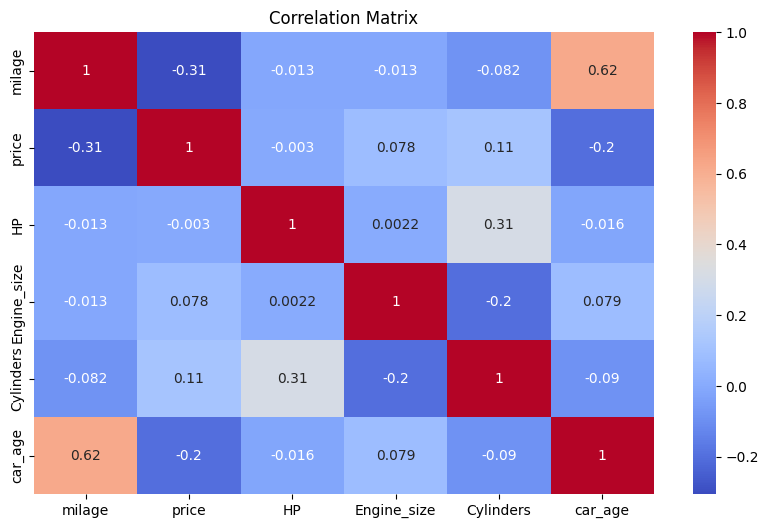

In [44]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Apply One-Hot Encoding

In [45]:
Category_cols = ['fuel_type', 'transmission', 'ext_col', 'int_col', 'accident']

existing_cols = [col for col in Category_cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

In [46]:
'''doing proper outlier handling + distribution fixing for price and milage.
We will log transform price and clip milage to remove extreme outliers.'''

df['milage'] = df['milage'].clip(
    df['milage'].quantile(0.01),
    df['milage'].quantile(0.99)
)

df['HP'] = df['HP'].clip(
    df['HP'].quantile(0.01),
    df['HP'].quantile(0.99)
)

df['price'] = np.log1p(df['price'])
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers in 'price': {outliers.shape[0]}")

#| Before | After                       |
#| ------ | --------------------------- |
#| 500000 | → capped at 99th percentile |


Number of outliers in 'price': 66


In [47]:
'''Removed outliers from price column. You can also choose to cap them instead of removing.'''

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

X = df.drop('price', axis=1)
y = df['price']

#👉 Keeps only “normal” price values
#👉 Improves model accuracy

Train Test the model

In [48]:
# 1. Split features & target
X = df.drop('price', axis=1)
y = df['price']

# 2. Encode ALL categorical columns
X = pd.get_dummies(X, drop_first=True)

# 3. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
numeric_cols = ['milage', 'HP', 'Engine_size', 'Cylinders', 'car_age']
scaler = StandardScaler()


X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [50]:
X_train.select_dtypes(include='object').columns

Index([], dtype='str')

In [51]:
for col in X_train.select_dtypes(include='object').columns:
    print(col, X_train[col].unique()[:5])

In [52]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [53]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6991429050560927
MAE: 0.3264001615987521
RMSE: 0.4345343772912493


In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

In [55]:
svr_model = SVR()
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10], 'degree': [2, 3, 4]}
]
grid = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1
)
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [56]:
grid.best_params_

{'C': 1, 'kernel': 'rbf'}

In [57]:
model_results = {}

best_model = grid.best_estimator_
predgrid = best_model.predict(X_test)

model_results['SVR'] = predgrid

print(model_results.keys())

dict_keys(['SVR'])


In [58]:
results = []

for model, preds in model_results.items():
    results.append({
        "Model": model,
        "R2 Score": r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds))   # ✅ fixed
    })

results_df = pd.DataFrame(results)
print(results_df)

  Model  R2 Score      RMSE
0   SVR  0.801464  0.352991


In [59]:
# Save the best model
import joblib
joblib.dump(best_model, 'best_used_car_price_model.pkl')

['best_used_car_price_model.pkl']

In [60]:
import numpy as np

# Create a template DataFrame with all columns from X_train, initialized to 0
input_df_for_prediction = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Fill in the numerical features (these are not scaled yet)
input_df_for_prediction['milage'] = 30000
input_df_for_prediction['HP'] = 150
input_df_for_prediction['Engine_size'] = 2.0
input_df_for_prediction['Cylinders'] = 4
input_df_for_prediction['car_age'] = 5

# Set the appropriate dummy variables to 1 for the desired categorical features.
# Based on common `drop_first=True` behavior and the error messages, we infer the intended categories
# and which dummy variables correspond to them.

# If 'fuel_type' is 'Gasoline', 'transmission' is 'Automatic', 'ext_col' is 'Black',
# 'int_col' is 'Black', and 'model_main' is 'Other' (the base categories after drop_first=True),
# then their corresponding dummy columns will remain 0.

# For 'accident': The error indicated 'accident_No' was a column seen at fit time,
# and 'accident_Yes' was unseen. This suggests `accident_Yes` was dropped.
# So, to represent 'No accident' (as intended by the original `accident_Yes: [0]`),
# we set `accident_No` to 1 if it exists as a column.
if 'accident_No' in input_df_for_prediction.columns:
    input_df_for_prediction['accident_No'] = 1 # For 'No accident'

# Scale the numerical features using the *already fitted* StandardScaler
# `numeric_cols` is available from a previous cell.
input_df_for_prediction[numeric_cols] = scaler.transform(input_df_for_prediction[numeric_cols])

# Make the prediction
prediction_price = best_model.predict(input_df_for_prediction)

print(f"Predicted log price: {prediction_price[0]}")
print(f"Predicted actual price: {np.expm1(prediction_price[0]):.2f}")

Predicted log price: 10.724267582382991
Predicted actual price: 45444.43
